In [82]:
# FOOD DELIVERY TIME PREDICTION 

import pandas as pd
import numpy as np

df = pd.read_csv("food_delivery.csv")
print(df.head())

print("\n" + "="*60)

print("Dataset Shape (Rows, Columns):")
print(df.shape)


     ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  4607     INDORES13DEL02                   37                      4.9   
1  B379     BANGRES18DEL02                   34                      4.5   
2  5D6D     BANGRES19DEL01                   23                      4.4   
3  7A6A    COIMBRES13DEL02                   38                      4.7   
4  70A2     CHENRES12DEL01                   32                      4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude Type_of_order Type_of_vehicle  Time_taken(min)  
0     

In [83]:
# Show all column names
print("Column Names:")
print(df.columns)

print("\n" + "="*60)

# Show data types of each column
print("Data Types:")
print(df.dtypes)

print("\n" + "="*60)

print("Dataset Information:")
print(df.info())

Column Names:
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

Data Types:
ID                              object
Delivery_person_ID              object
Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Type_of_order                   object
Type_of_vehicle                 object
Time_taken(min)                  int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------

In [84]:
# ------------------------------------------------------------
# Identify Target Variable
# ------------------------------------------------------------
# TARGET VARIABLE:
print("\n" + "="*60)
print("TARGET VARIABLE")
print("="*60)

target_variable = "Time_taken(min)"

print("Target Variable:")
print(target_variable)


# ------------------------------------------------------------
# Identify Input Features
# ------------------------------------------------------------


print("\n" + "="*60)
print("INPUT FEATURES")
print("="*60)

input_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Type_of_order",
    "Type_of_vehicle"
]

print("Input Features Used for Prediction:")

for feature in input_features:
    print("-", feature)

# ------------------------------------------------------------
# Columns to Ignore
# ------------------------------------------------------------

print("\n" + "="*60)
print("COLUMNS TO REMOVE")
print("="*60)

remove_columns = [
    "ID",
    "Delivery_person_ID"
]

for col in remove_columns:
    print("-", col)



TARGET VARIABLE
Target Variable:
Time_taken(min)

INPUT FEATURES
Input Features Used for Prediction:
- Delivery_person_Age
- Delivery_person_Ratings
- Restaurant_latitude
- Restaurant_longitude
- Delivery_location_latitude
- Delivery_location_longitude
- Type_of_order
- Type_of_vehicle

COLUMNS TO REMOVE
- ID
- Delivery_person_ID


In [85]:
# visualization for outlier checking
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [86]:

df.drop(
    ["ID", "Delivery_person_ID"],
    axis=1,
    inplace=True
)

print("\nRemoved unnecessary columns successfully")



Removed unnecessary columns successfully


In [87]:
# Check Missing Values

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(df.isnull().sum())

# Handle Missing Values

# Numerical columns -> fill using mean
# Categorical columns -> fill using mode

numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Time_taken(min)"
]

categorical_columns = [
    "Type_of_order",
    "Type_of_vehicle"
]

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled successfully")



MISSING VALUES CHECK
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

Missing values handled successfully


In [88]:
# Remove Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

df = df.drop_duplicates()

print("Duplicates removed successfully")

Number of Duplicate Rows: 28
Duplicates removed successfully


In [89]:
# Create Distance_km Feature
import math

# Haversine Formula Function

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  

    # Convert degrees to radians
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    # Difference between coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(
        math.sqrt(a),
        math.sqrt(1 - a)
    )

    distance = R * c

    return distance

df["Distance_km"] = df.apply(
    lambda row: calculate_distance(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

df.drop(
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ],
    axis=1,
    inplace=True
)

print("\nLatitude and Longitude columns removed")
print("\nUpdated Columns:")
print(df.columns)
numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Distance_km",
    "Time_taken(min)"
]


Latitude and Longitude columns removed

Updated Columns:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Type_of_order',
       'Type_of_vehicle', 'Time_taken(min)', 'Distance_km'],
      dtype='object')


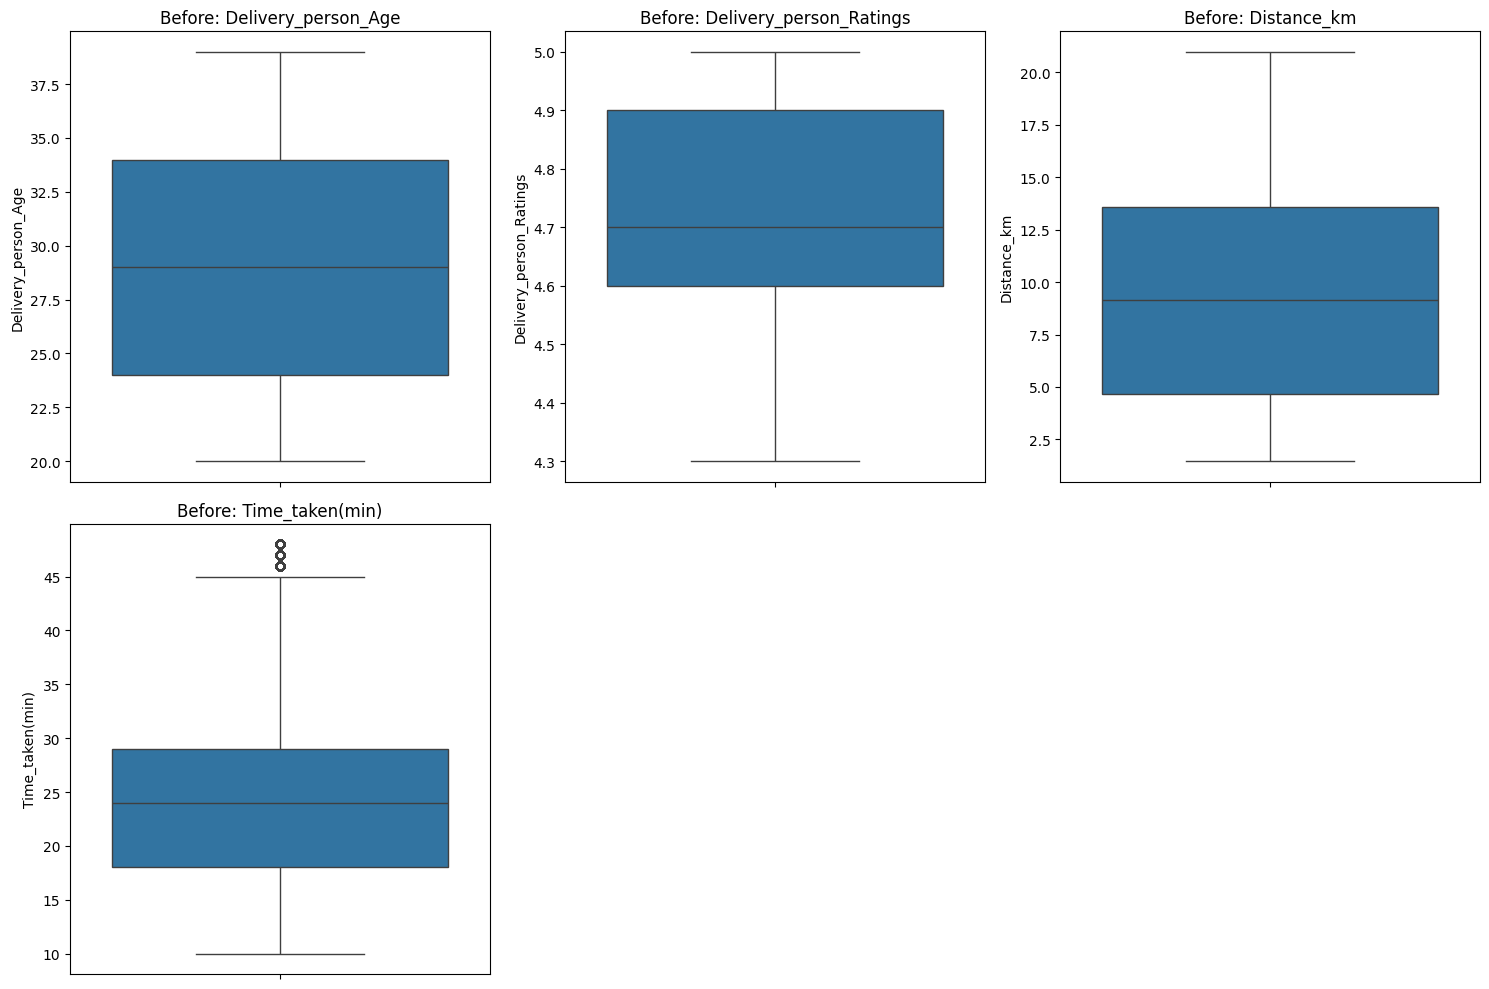


Outliers handled using IQR method
Original Shape : (39302, 6)
Cleaned Shape  : (38643, 6)


In [ ]:
# Outlier Detection using Boxplots 

import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(f"Before: {col}")

plt.tight_layout()
plt.show()

# Outlier Handling using IQR Method 

df_clean = df.copy()

for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]

print("\nOutliers handled using IQR method")
print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)

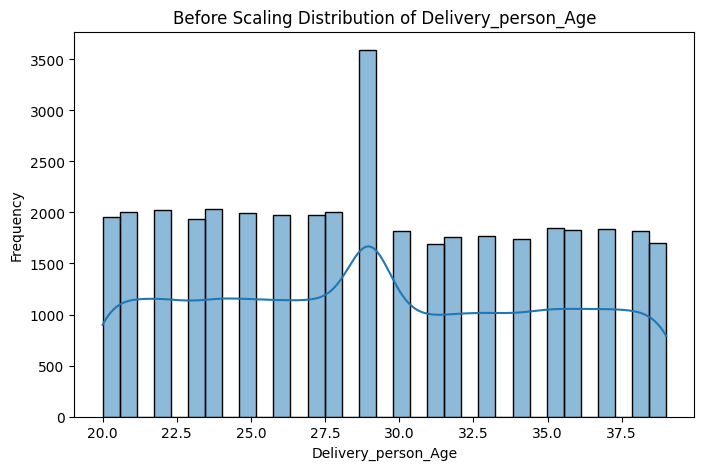

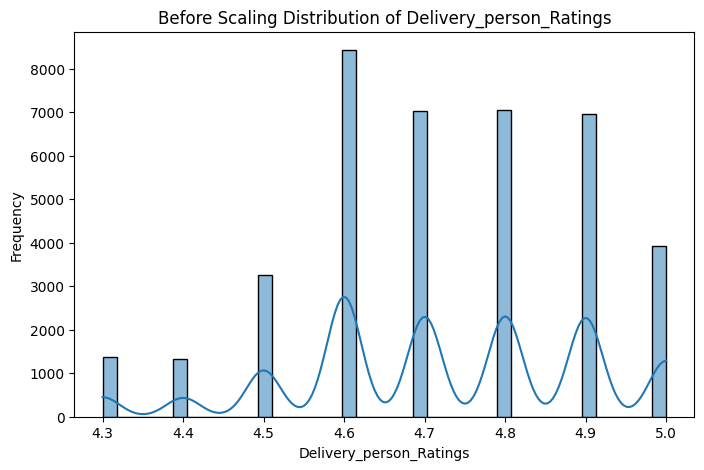

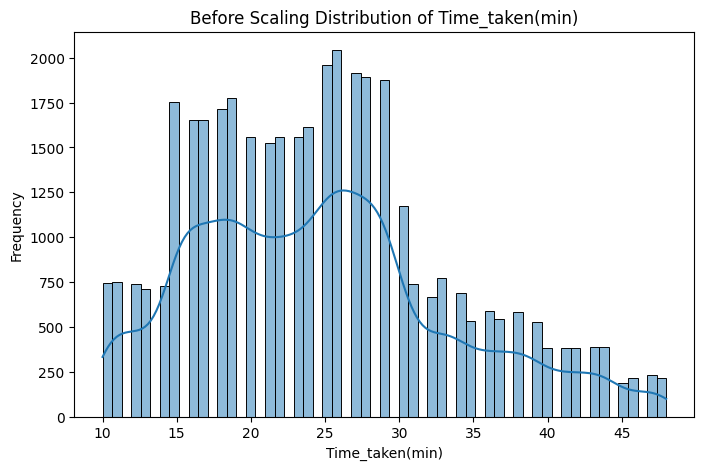

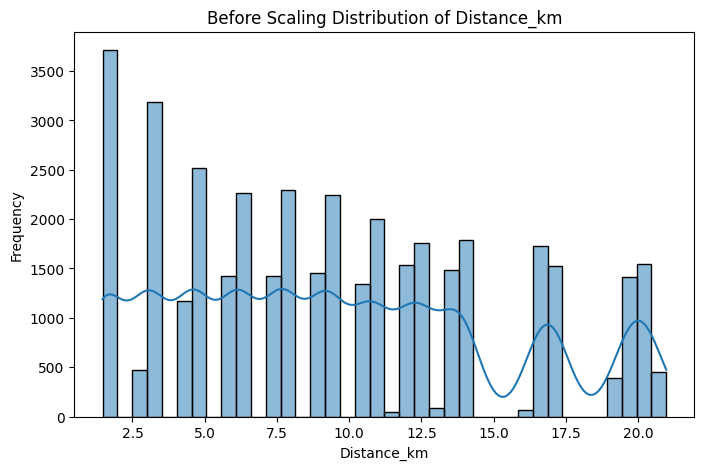

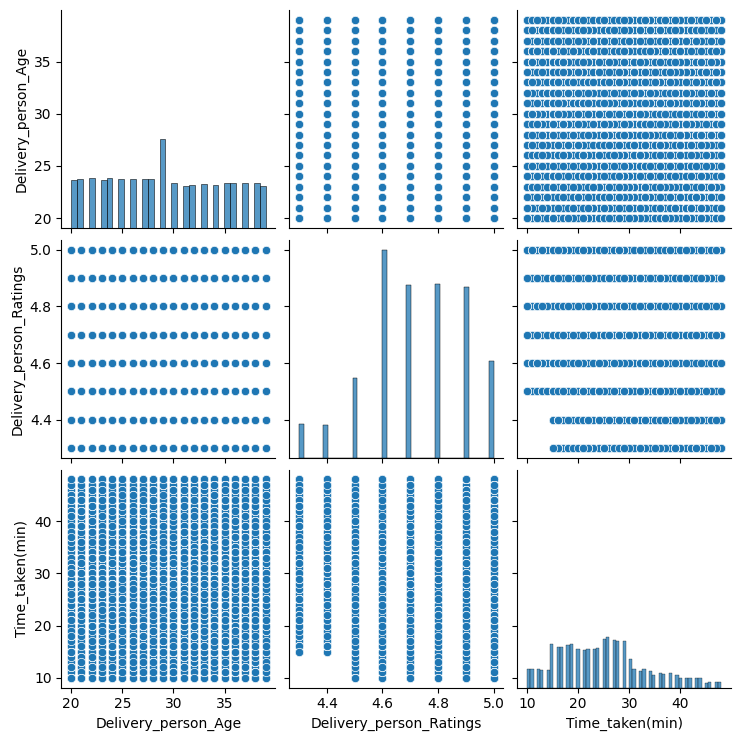

In [ ]:
# visualization before scaling

numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Time_taken(min)",
    "Distance_km"
]

# Histogram Visualization

# Shows distribution of values before scaling

for col in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Before Scaling Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


# Pairplot Visualization

# Visual relationship between important features

selected_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Time_taken(min)"
]

sns.pairplot(df[selected_columns])

plt.show()

In [97]:
# Encode Categorical Columns

label_encoder = LabelEncoder()

df["Type_of_order"] = label_encoder.fit_transform(
    df["Type_of_order"]
)

df["Type_of_vehicle"] = label_encoder.fit_transform(
    df["Type_of_vehicle"]
)

print("Categorical columns encoded successfully")

# Feature Scaling

features_to_scale = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Distance_km",
]

scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

print("Feature scaling completed successfully")

Categorical columns encoded successfully
Feature scaling completed successfully


In [98]:
#  Save Cleaned Dataset
df.to_csv(
    "food_delivery_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved as:")
print("food_delivery_cleaned.csv")


Cleaned dataset saved as:
food_delivery_cleaned.csv


In [99]:
df = pd.read_csv("food_delivery_cleaned.csv")
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(39302, 6)

Column Names:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Type_of_order',
       'Type_of_vehicle', 'Time_taken(min)', 'Distance_km'],
      dtype='object')

Data Types:
Delivery_person_Age        float64
Delivery_person_Ratings    float64
Type_of_order                int64
Type_of_vehicle              int64
Time_taken(min)              int64
Distance_km                float64
dtype: object


In [101]:
# Mean, Median, Mode
print("\n" + "="*60)
print("MEAN, MEDIAN, MODE")
print("="*60)

numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Distance_km",
    "Time_taken(min)"
]

for col in numerical_columns:
    print(f"\nColumn: {col}")
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode()[0])

# Variance and Standard Deviation

for col in numerical_columns:
    print(f"\nColumn: {col}")
    print("Variance           :", df[col].var())
    print("Standard Deviation :", df[col].std())



MEAN, MEDIAN, MODE

Column: Delivery_person_Age
Mean   : -1.8079047777723783e-17
Median : -0.0393831753282951
Mode   : -0.0393831753282951

Column: Delivery_person_Ratings
Mean   : 1.699430491106036e-17
Median : -0.1204517085691423
Mode   : -0.6847612866099692

Column: Distance_km
Mean   : -2.350276211104092e-17
Median : -0.0699267427882333
Mode   : -1.1408008077135947

Column: Time_taken(min)
Mean   : 24.774489847844894
Median : 24.0
Mode   : 26

Column: Delivery_person_Age
Variance           : 1.0000254446451744
Standard Deviation : 1.0000127222416595

Column: Delivery_person_Ratings
Variance           : 1.0000254446451744
Standard Deviation : 1.0000127222416595

Column: Distance_km
Variance           : 1.0000254446451746
Standard Deviation : 1.0000127222416595

Column: Time_taken(min)
Variance           : 73.41467910540315
Standard Deviation : 8.56823663920431


In [102]:
# Correlation Matrix

print("CORRELATION MATRIX")
print("="*60)

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

CORRELATION MATRIX
                         Delivery_person_Age  Delivery_person_Ratings  \
Delivery_person_Age                 1.000000                -0.054089   
Delivery_person_Ratings            -0.054089                 1.000000   
Type_of_order                      -0.002849                -0.003650   
Type_of_vehicle                    -0.005577                 0.027904   
Time_taken(min)                     0.275639                -0.154452   
Distance_km                        -0.033228                -0.023869   

                         Type_of_order  Type_of_vehicle  Time_taken(min)  \
Delivery_person_Age          -0.002849        -0.005577         0.275639   
Delivery_person_Ratings      -0.003650         0.027904        -0.154452   
Type_of_order                 1.000000         0.004261         0.003908   
Type_of_vehicle               0.004261         1.000000        -0.089311   
Time_taken(min)               0.003908        -0.089311         1.000000   
Distance_km  

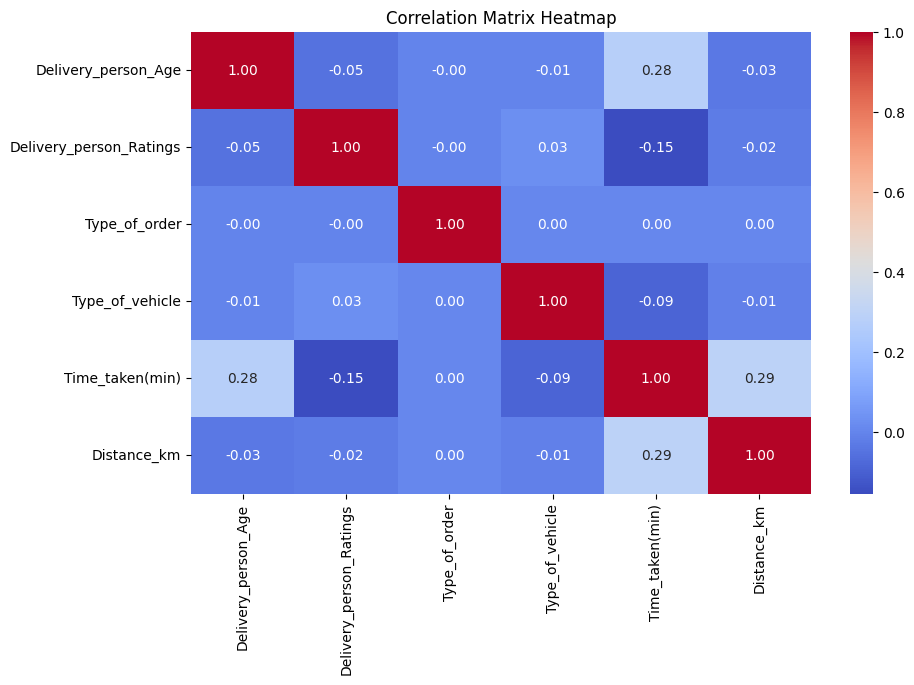

FEATURE RELATIONSHIPS


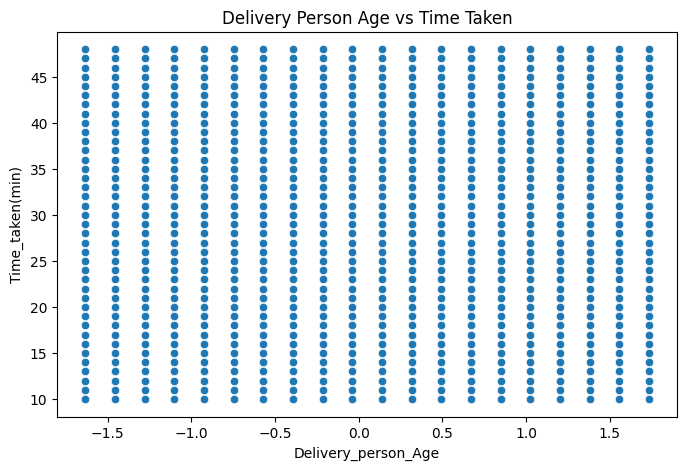

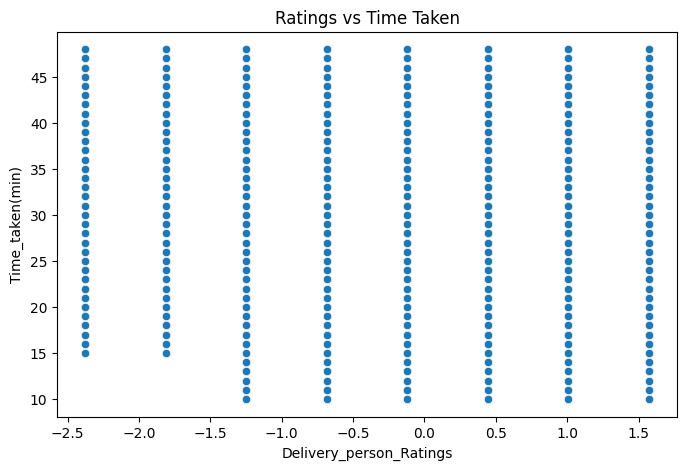

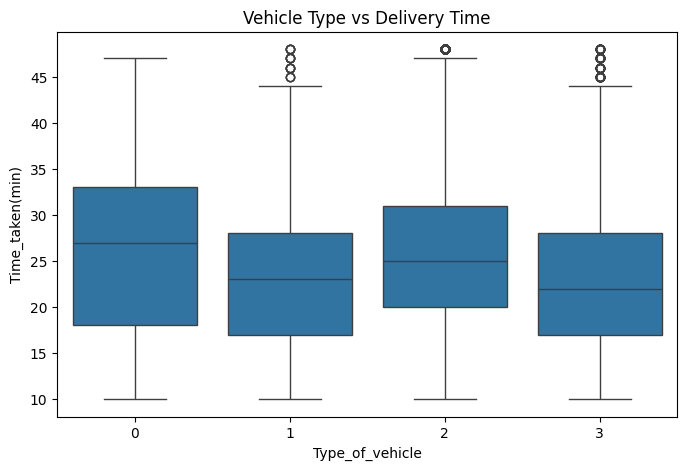

In [103]:
# Heatmap for Correlation

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.show()


# Relationship Between Features

print("FEATURE RELATIONSHIPS")
print("="*60)


# Age vs Delivery Time
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_person_Age",
    y="Time_taken(min)",
    data=df
)

plt.title("Delivery Person Age vs Time Taken")
plt.show()


# Ratings vs Delivery Time
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_person_Ratings",
    y="Time_taken(min)",
    data=df
)

plt.title("Ratings vs Time Taken")
plt.show()


# Vehicle Type vs Delivery Time
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Type_of_vehicle",
    y="Time_taken(min)",
    data=df
)

plt.title("Vehicle Type vs Delivery Time")
plt.show()


In [ ]:
# Model Building (Core ML Part)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [106]:
# Features used for prediction
X = df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Distance_km",
        "Type_of_order",
        "Type_of_vehicle"
    ]
]

# Target variable
y = df["Time_taken(min)"]

# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain-Test Split Completed")


Train-Test Split Completed


In [ ]:
# ------------------------------------------------------------
#Linear Regression Model
# ------------------------------------------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

# ------------------------------------------------------------
# Random Forest Regressor (Optional Better Model)
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")


Linear Regression Model Trained Successfully
Random Forest Model Trained Successfully


In [108]:
# Sample Prediction

sample_prediction_lr = lr_model.predict(X_test[:5])

sample_prediction_rf = rf_model.predict(X_test[:5])

print("\nSample Predictions using Linear Regression:")
print(sample_prediction_lr)

print("\nSample Predictions using Random Forest:")
print(sample_prediction_rf)




Sample Predictions using Linear Regression:
[19.39561839 25.5659534  29.12613992 28.29342321 22.92355906]

Sample Predictions using Random Forest:
[20.69       21.40533333 28.26       29.18       28.1       ]


In [110]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Evaluation Metrics

print("\nLINEAR REGRESSION RESULTS")
print("="*40)

print("MAE  :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2 Score :", r2_score(y_test, lr_pred))


print("\nRANDOM FOREST RESULTS")
print("="*40)

print("MAE  :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2 Score :", r2_score(y_test, rf_pred))




LINEAR REGRESSION RESULTS
MAE  : 6.153143199126073
RMSE : 7.633092810334249
R2 Score : 0.19785367199937554

RANDOM FOREST RESULTS
MAE  : 6.072457876739297
RMSE : 7.640410624580708
R2 Score : 0.19631490606929747


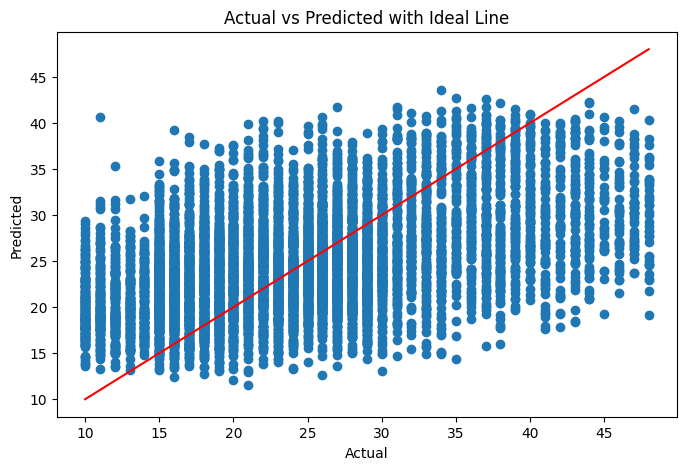


FEATURE IMPORTANCE


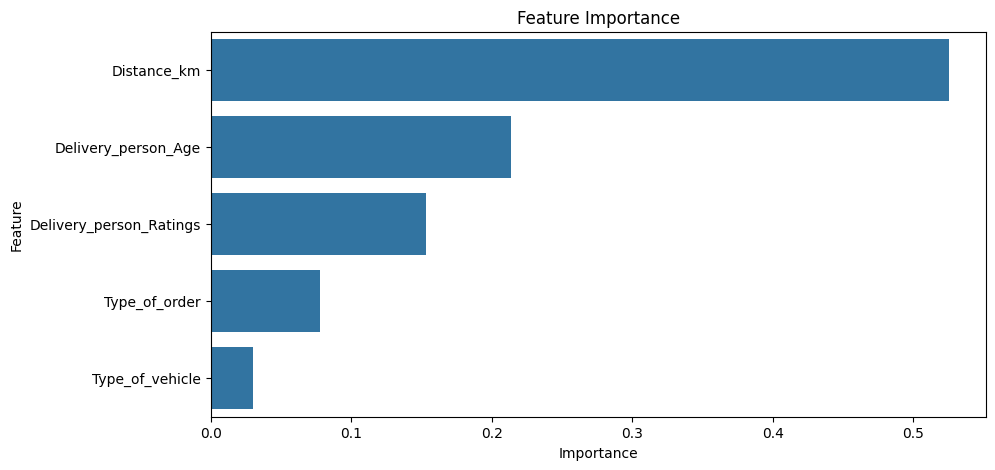

In [111]:
# Actual vs Predicted Graph

plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted with Ideal Line")
plt.show()

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print("\nFEATURE IMPORTANCE")
print("="*40)
importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

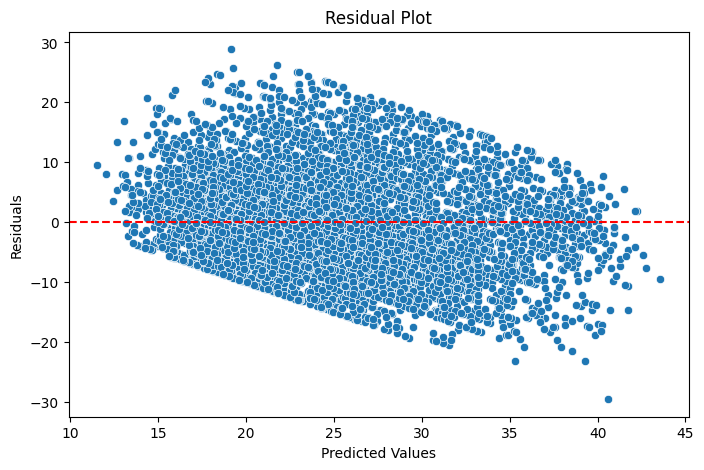

In [112]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=rf_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()